In [1]:
import sys
print(sys.executable)

import tensorflow as tf
print(tf.__version__)

/opt/anaconda3/bin/python
2.21.0


In [2]:
import os

CAT_DIR = "/Users/dare/CaseStudy6Files/dog-cat-dataset/data/cats"
DOG_DIR = "/Users/dare/CaseStudy6Files/dog-cat-dataset/data/dogs"

print(os.path.exists(CAT_DIR), len(os.listdir(CAT_DIR)))
print(os.path.exists(DOG_DIR), len(os.listdir(DOG_DIR)))

True 349
True 348


# CNN Capstone Lab Project: Pet Classification With Model Comparison

**Author:** Darious Brown  
**Task:** Binary image classification of cats vs. dogs using four CNN architectures: Custom CNN, VGG16, ResNet50, and EfficientNetB0.

This notebook is designed to run locally against an image-folder dataset:

```python
CAT_DIR = "/Users/dare/CaseStudy6Files/dog-cat-dataset/data/cats"
DOG_DIR = "/Users/dare/CaseStudy6Files/dog-cat-dataset/data/dogs"
```

The notebook creates train/validation/test splits, trains all required models, evaluates performance, extracts features, creates t-SNE visualizations, and exports reproducible results files.

In [3]:
# =============================
# 1. Environment Setup
# =============================
import os
import json
import time
import random
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, KFold

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU devices: []


In [4]:
# =============================
# 2. Project Configuration
# =============================
CAT_DIR = "/Users/dare/CaseStudy6Files/dog-cat-dataset/data/cats"
DOG_DIR = "/Users/dare/CaseStudy6Files/dog-cat-dataset/data/dogs"

PROJECT_DIR = Path.cwd() / 'cnn_capstone_outputs'
DATA_SPLIT_DIR = PROJECT_DIR / 'split_data'
RESULTS_DIR = PROJECT_DIR / 'results'
VISUALS_DIR = PROJECT_DIR / 'visuals'
MODELS_DIR = PROJECT_DIR / 'models'

for d in [PROJECT_DIR, DATA_SPLIT_DIR, RESULTS_DIR, VISUALS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
CLASS_NAMES = ['cats', 'dogs']

print('Project output folder:', PROJECT_DIR)

Project output folder: /Users/dare/img_align_celeba/cnn_capstone_outputs


In [5]:
# =============================
# 3. Validate Image Files
# =============================
def get_valid_images(folder):
    folder = Path(folder)
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    files = []
    for p in folder.rglob('*'):
        if p.suffix.lower() in valid_exts:
            try:
                with Image.open(p) as img:
                    img.verify()
                files.append(p)
            except (UnidentifiedImageError, OSError):
                print('Skipping invalid image:', p)
    return files

cat_files = get_valid_images(CAT_DIR)
dog_files = get_valid_images(DOG_DIR)

print(f'Valid cat images: {len(cat_files)}')
print(f'Valid dog images: {len(dog_files)}')
assert len(cat_files) >= 1 and len(dog_files) >= 1, 'No valid images found. Check CAT_DIR and DOG_DIR.'

Valid cat images: 349
Valid dog images: 348


In [6]:
# =============================
# 4. Create Train/Validation/Test Folder Split
# =============================
def reset_dir(path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

reset_dir(DATA_SPLIT_DIR)
for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        (DATA_SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def split_and_copy(files, class_name, test_size=0.15, val_size=0.20):
    files = [str(f) for f in files]
    train_val, test = train_test_split(files, test_size=test_size, random_state=SEED, shuffle=True)
    train, val = train_test_split(train_val, test_size=val_size, random_state=SEED, shuffle=True)
    split_map = {'train': train, 'val': val, 'test': test}
    for split, split_files in split_map.items():
        for src in split_files:
            src_path = Path(src)
            dst = DATA_SPLIT_DIR / split / class_name / src_path.name
            shutil.copy2(src_path, dst)
    return {k: len(v) for k, v in split_map.items()}

cat_counts = split_and_copy(cat_files, 'cats')
dog_counts = split_and_copy(dog_files, 'dogs')

split_summary = pd.DataFrame({
    'cats': cat_counts,
    'dogs': dog_counts
}).T
split_summary['total'] = split_summary.sum(axis=1)
print(split_summary)

      train  val  test  total
cats    236   60    53    349
dogs    236   59    53    348


In [7]:
# =============================
# 5. Data Generators
# =============================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    zoom_range=0.10
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    DATA_SPLIT_DIR / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    DATA_SPLIT_DIR / 'val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    DATA_SPLIT_DIR / 'test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_indices = train_gen.class_indices
print('Class indices:', class_indices)

Found 472 images belonging to 2 classes.
Found 119 images belonging to 2 classes.
Found 106 images belonging to 2 classes.
Class indices: {'cats': 0, 'dogs': 1}


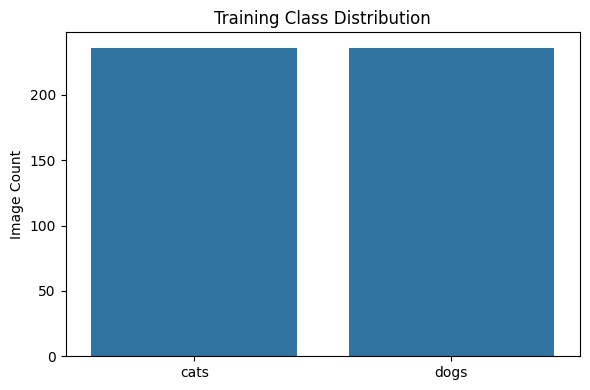

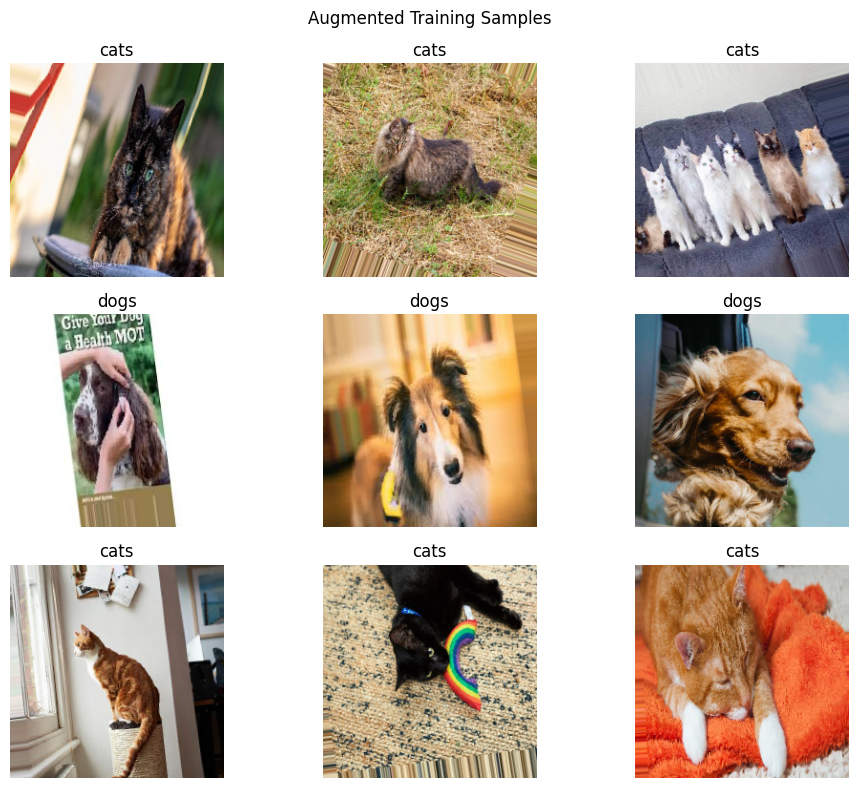

In [8]:
# =============================
# 6. Data Visualization
# =============================
plt.figure(figsize=(6,4))
counts = [len(list((DATA_SPLIT_DIR/'train'/cls).glob('*'))) for cls in CLASS_NAMES]
sns.barplot(x=CLASS_NAMES, y=counts)
plt.title('Training Class Distribution')
plt.ylabel('Image Count')
plt.tight_layout()
plt.savefig(VISUALS_DIR / 'class_distribution.png', dpi=300)
plt.show()

images, labels = next(train_gen)
plt.figure(figsize=(10, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(CLASS_NAMES[np.argmax(labels[i])])
    plt.axis('off')
plt.suptitle('Augmented Training Samples')
plt.tight_layout()
plt.savefig(VISUALS_DIR / 'augmented_samples.png', dpi=300)
plt.show()

In [9]:
# =============================
# 7. Model Builders
# =============================
def build_simple_cnn(img_size=IMG_SIZE, dropout_rate=0.5):
    model = models.Sequential(name='Simple_Custom_CNN')
    model.add(layers.Input(shape=(img_size, img_size, 3)))
    model.add(layers.Conv2D(32, (3,3), activation='relu', name='conv1'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), activation='relu', name='conv2'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(128, (3,3), activation='relu', name='last_conv'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(2, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_transfer_model(base_name, img_size=IMG_SIZE, dropout_rate=0.5):
    if base_name == 'VGG16':
        base = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
    elif base_name == 'ResNet50':
        base = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
    elif base_name == 'EfficientNetB0':
        base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
    else:
        raise ValueError('Unsupported base model')
    base.trainable = False
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(2, activation='softmax')(x)
    model = Model(inputs, outputs, name=f'{base_name}_Transfer_Learning')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_builders = {
    'Simple CNN': lambda: build_simple_cnn(),
    'VGG16': lambda: build_transfer_model('VGG16'),
    'ResNet50': lambda: build_transfer_model('ResNet50'),
    'EfficientNetB0': lambda: build_transfer_model('EfficientNetB0')
}

In [10]:
# =============================
# 8. Training and Evaluation Functions
# =============================

def get_callbacks():
    return [
        EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]


def count_params(model):
    total = model.count_params()
    trainable = int(
        np.sum([
            tf.keras.backend.count_params(w)
            for w in model.trainable_weights
        ])
    )
    non_trainable = total - trainable
    return total, trainable, non_trainable


def evaluate_model(model, model_name):
    test_gen.reset()

    start = time.time()
    y_prob = model.predict(test_gen, verbose=1)
    inference_time = time.time() - start

    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred)

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    return {
        "test_accuracy": float(acc),
        "weighted_f1_score": float(f1),
        "inference_time_seconds": float(inference_time),
        "inference_time_per_image_ms": float(
            (inference_time / max(1, len(y_true))) * 1000
        ),
        "confusion_matrix": cm.tolist(),
        "classification_report": report
    }


def plot_history(history, model_name):
    hist = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Train Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Training Accuracy - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        VISUALS_DIR / f"accuracy_{model_name.lower().replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"Training Loss - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        VISUALS_DIR / f"loss_{model_name.lower().replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


def plot_confusion(cm, model_name):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(
        VISUALS_DIR / f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


Training: Simple CNN


Model: "Simple_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 380ms/step - accuracy: 0.4936 - loss: 0.7617 - val_accuracy: 0.5630 - val_loss: 0.6802 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 354ms/step - accuracy: 0.5064 - loss: 0.6938 - val_accuracy: 0.5294 - val_loss: 0.6874 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 349ms/step - accuracy: 0.5614 - loss: 0.6866 - val_accuracy: 0.4958 - val_loss: 0.6975 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.5760 - loss: 0.6883
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 345ms/step - accuracy: 0.5551 - loss: 0.6859 - val_accuracy: 0.5042 - val_loss: 0.6880 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 346ms/step - accuracy: 0.5530 - loss: 0.6702 - val_accuracy: 0.6134 - val_loss: 0.6736 - learning_rate: 2.0000e-04
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 361ms/step - accuracy: 0.6398 - loss: 

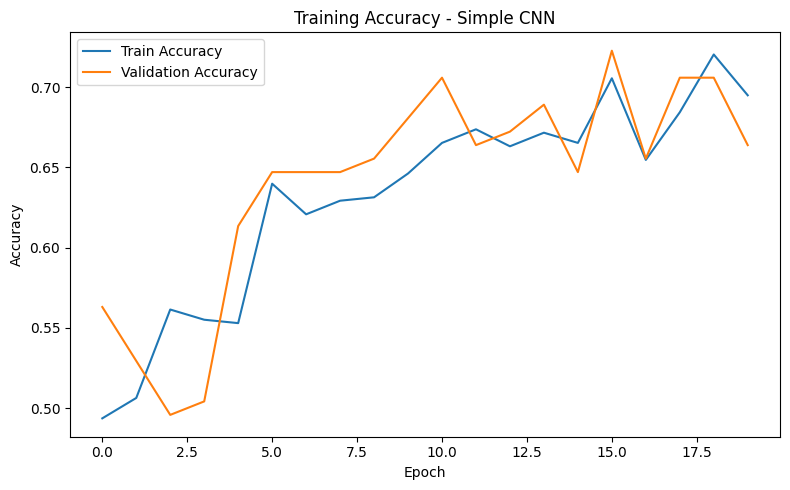

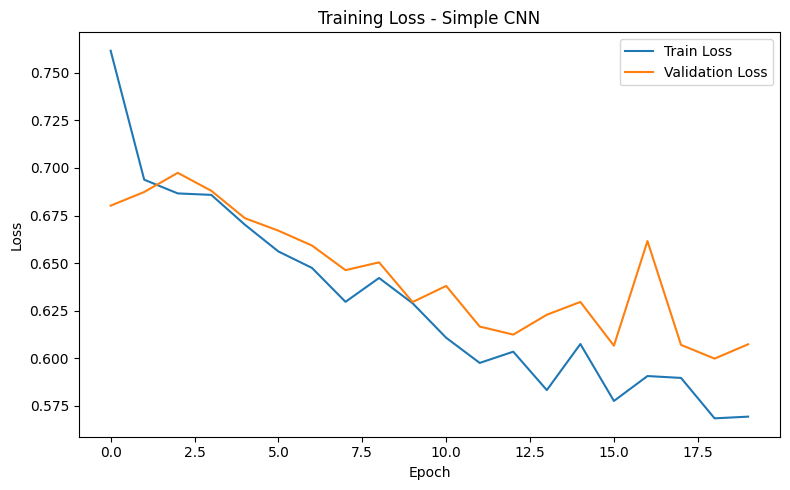

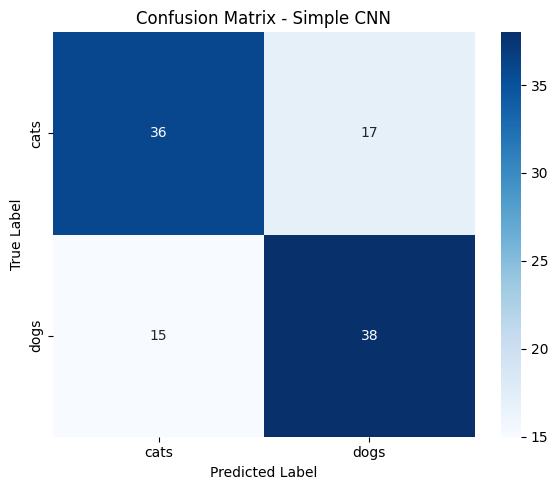


Training: VGG16


Model: "VGG16_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5593 - loss: 0.7333 - val_accuracy: 0.6807 - val_loss: 0.6243 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6631 - loss: 0.6031 - val_accuracy: 0.7647 - val_loss: 0.5552 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7521 - loss: 0.5553 - val_accuracy: 0.8235 - val_loss: 0.5126 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7627 - loss: 0.5003 - val_accuracy: 0.7731 - val_loss: 0.4645 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7881 - loss: 0.4713 - val_accuracy: 0.7899 - val_loss: 0.4411 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8178 - loss: 0.4226 - val_accuracy: 0.7815 - val_loss: 0.4168 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8030 - loss: 0.4152 - val_accur

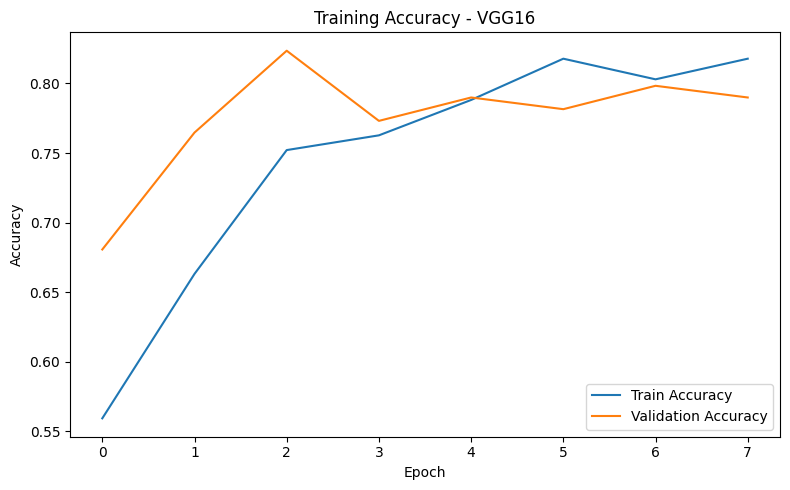

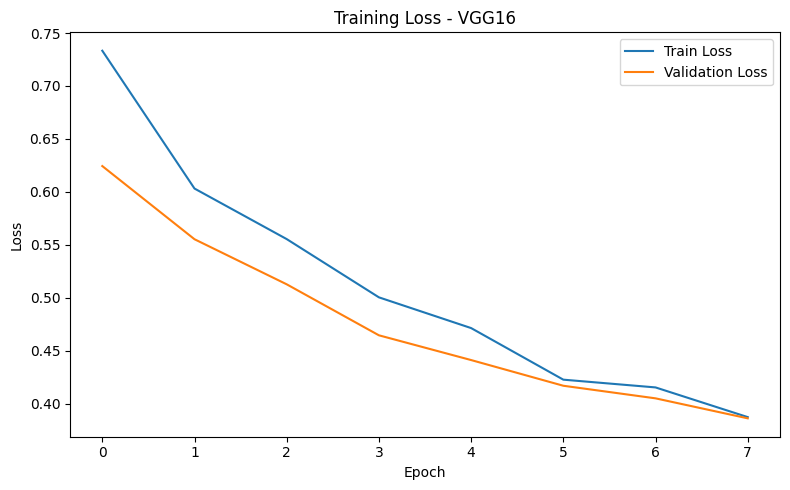

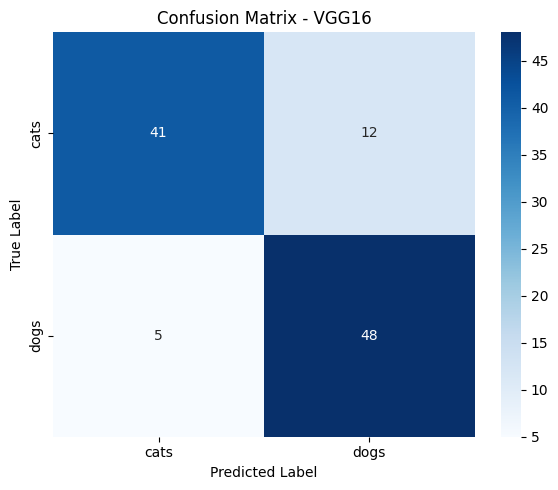


Training: ResNet50


Model: "ResNet50_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 799ms/step - accuracy: 0.5233 - loss: 0.9087 - val_accuracy: 0.5882 - val_loss: 0.6805 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 716ms/step - accuracy: 0.5487 - loss: 0.7235 - val_accuracy: 0.6134 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 726ms/step - accuracy: 0.5636 - loss: 0.6926 - val_accuracy: 0.6050 - val_loss: 0.6734 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 735ms/step - accuracy: 0.5233 - loss: 0.6999 - val_accuracy: 0.6471 - val_loss: 0.6756 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.5448 - loss: 0.6824
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 733ms/step - accuracy: 0.5254 - loss: 0.6862 - val_accuracy: 0.5714 - val_loss: 0.6762 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 737ms/step - accuracy: 0.5254 - loss

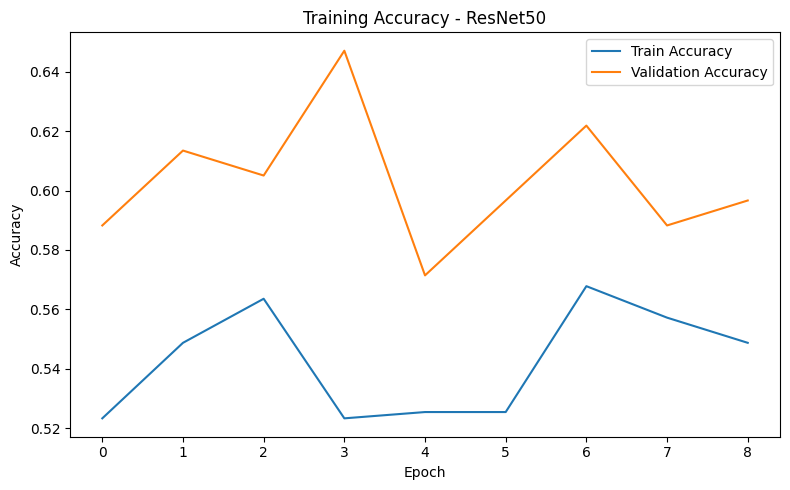

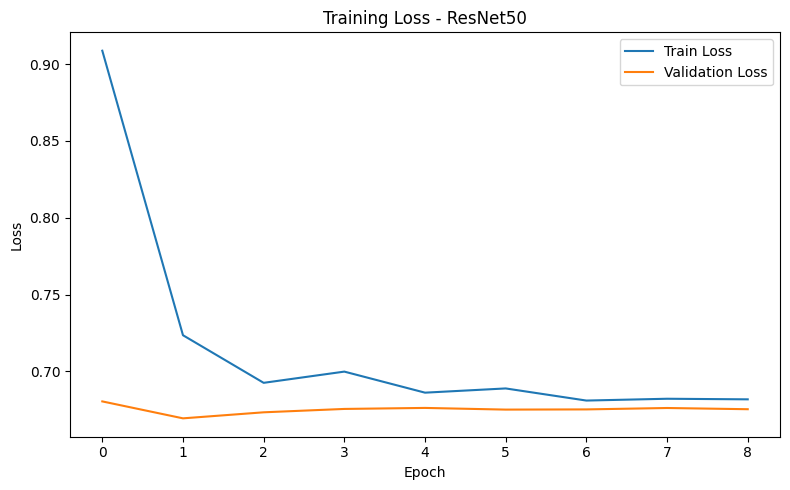

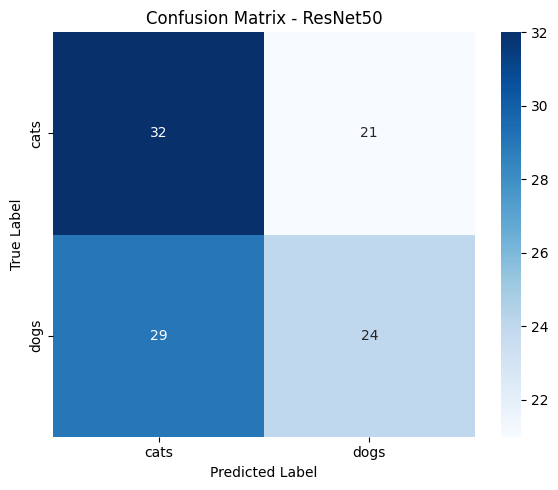


Training: EfficientNetB0


Model: "EfficientNetB0_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,797 (16.07 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

None
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 394ms/step - accuracy: 0.4555 - loss: 0.7711 - val_accuracy: 0.5042 - val_loss: 0.7001 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 290ms/step - accuracy: 0.4873 - loss: 0.7084 - val_accuracy: 0.4958 - val_loss: 0.6983 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 297ms/step - accuracy: 0.4809 - loss: 0.7038 - val_accuracy: 0.5042 - val_loss: 0.6971 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 304ms/step - accuracy: 0.4407 - loss: 0.7142 - val_accuracy: 0.4958 - val_loss: 0.6940 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 306ms/step - accuracy: 0.4894 - loss: 0.6942 - val_accuracy: 0.5042 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 298ms/step - accuracy: 0.5021 - loss: 0.6941 - val_accuracy: 0.5042 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

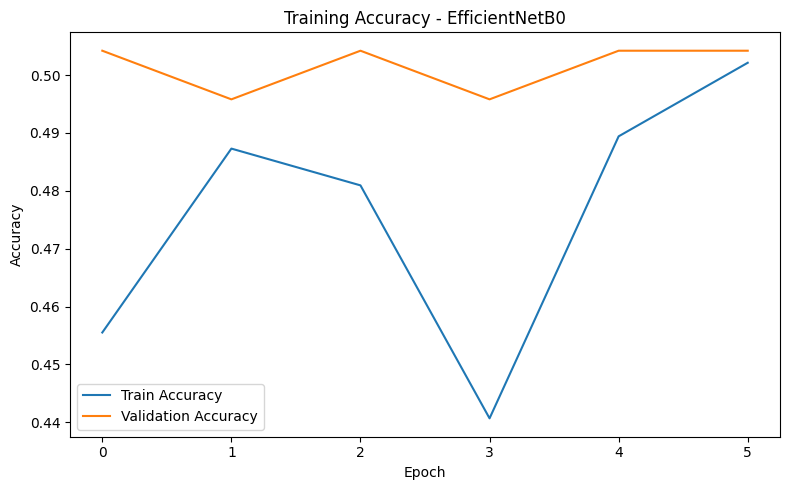

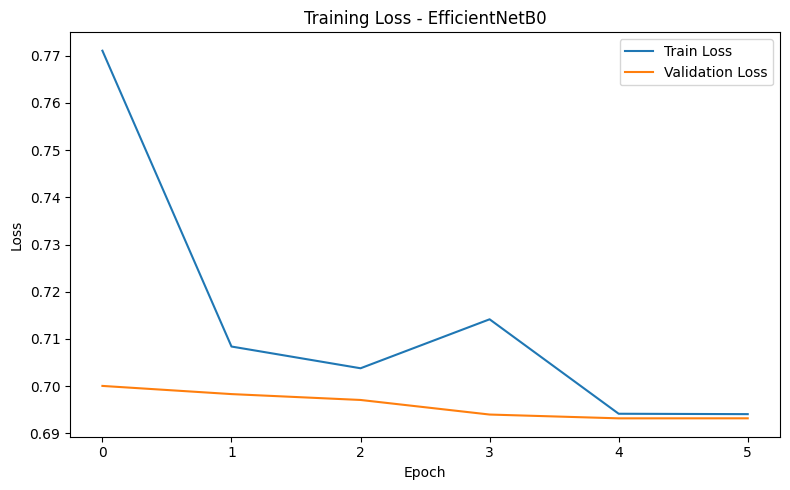

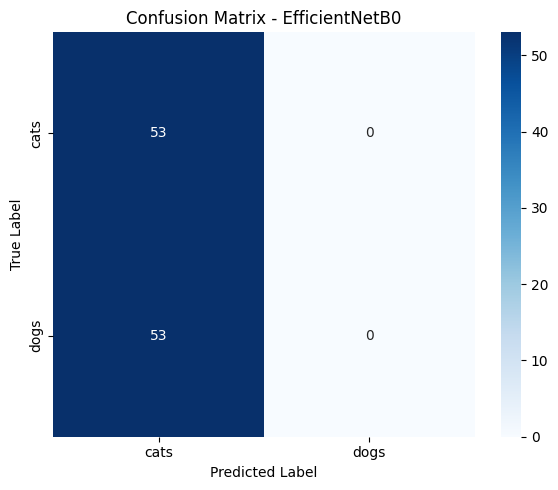

In [11]:
# =============================
# 9. Train All Four Required Models
# =============================
all_results = {}
histories = {}
trained_models = {}

for model_name, builder in model_builders.items():
    print('\n' + '='*80)
    print(f'Training: {model_name}')
    print('='*80)
    model = builder()
    total_params, trainable_params, non_trainable_params = count_params(model)
    print(model.summary())
    start_train = time.time()
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=get_callbacks(),
        verbose=1
    )
    training_time = time.time() - start_train
    eval_metrics = evaluate_model(model, model_name)
    eval_metrics.update({
        'training_time_seconds': float(training_time),
        'total_parameters': int(total_params),
        'trainable_parameters': int(trainable_params),
        'non_trainable_parameters': int(non_trainable_params),
        'epochs_trained': len(history.history['loss']),
        'best_val_accuracy': float(max(history.history['val_accuracy'])),
        'final_train_accuracy': float(history.history['accuracy'][-1]),
        'final_val_accuracy': float(history.history['val_accuracy'][-1])
    })
    all_results[model_name] = eval_metrics
    histories[model_name] = history.history
    trained_models[model_name] = model
    plot_history(history, model_name)
    plot_confusion(np.array(eval_metrics['confusion_matrix']), model_name)
    model.save(MODELS_DIR / f'{model_name.lower().replace(" ", "_")}.keras')


Extracting Features: Simple CNN
Layer: last_conv
Shape: (106, 346112)
Sparsity: 93.70%
Mean Activation: 0.0009
Std Activation: 0.0055


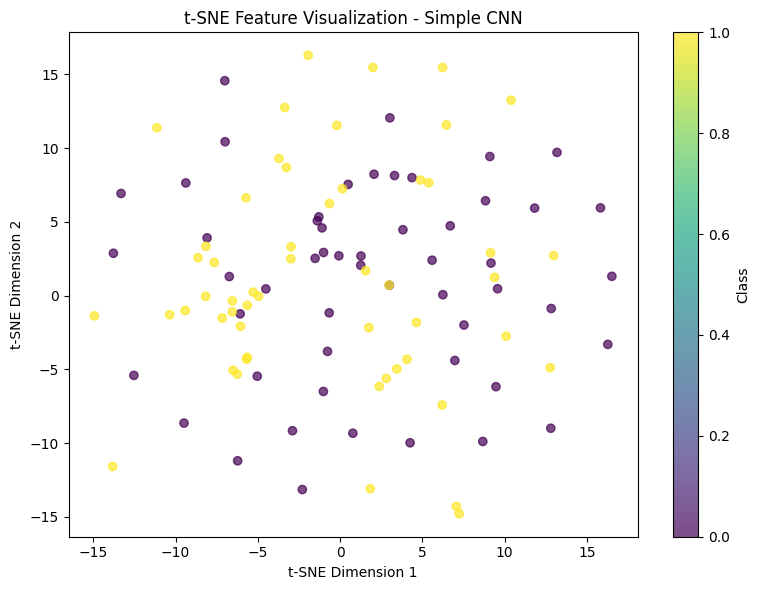


Extracting Features: VGG16
Layer: vgg16
Shape: (106, 25088)
Sparsity: 74.33%
Mean Activation: 0.1618
Std Activation: 0.5626


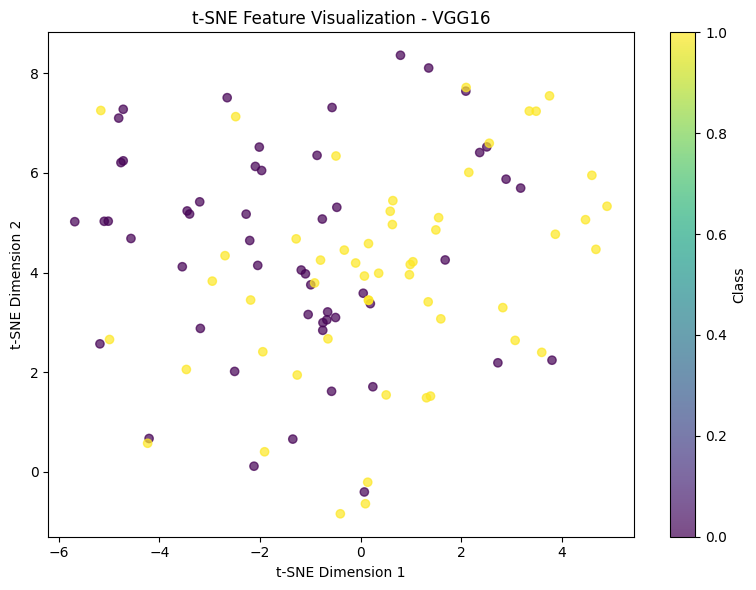


Extracting Features: ResNet50
Layer: resnet50
Shape: (106, 100352)
Sparsity: 94.56%
Mean Activation: 0.1087
Std Activation: 0.7401


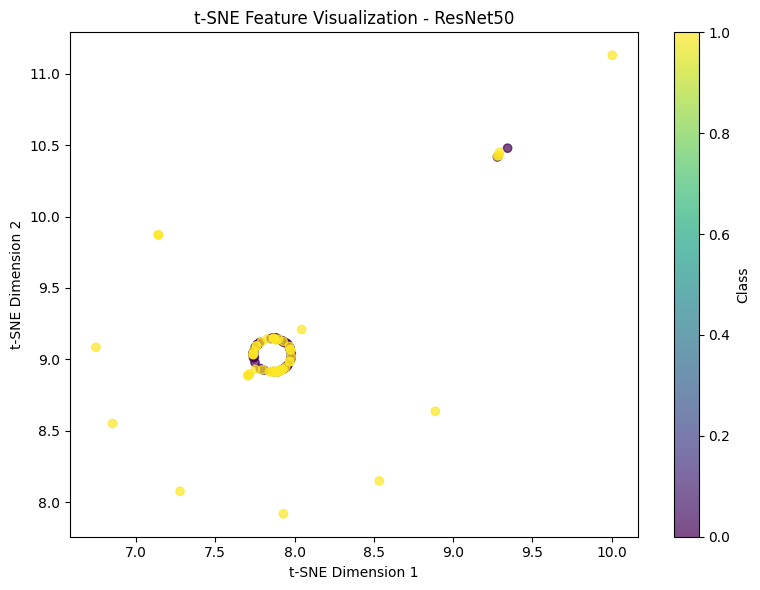


Extracting Features: EfficientNetB0
Layer: efficientnetb0
Shape: (106, 62720)
Sparsity: 0.00%
Mean Activation: -0.1043
Std Activation: 0.4612


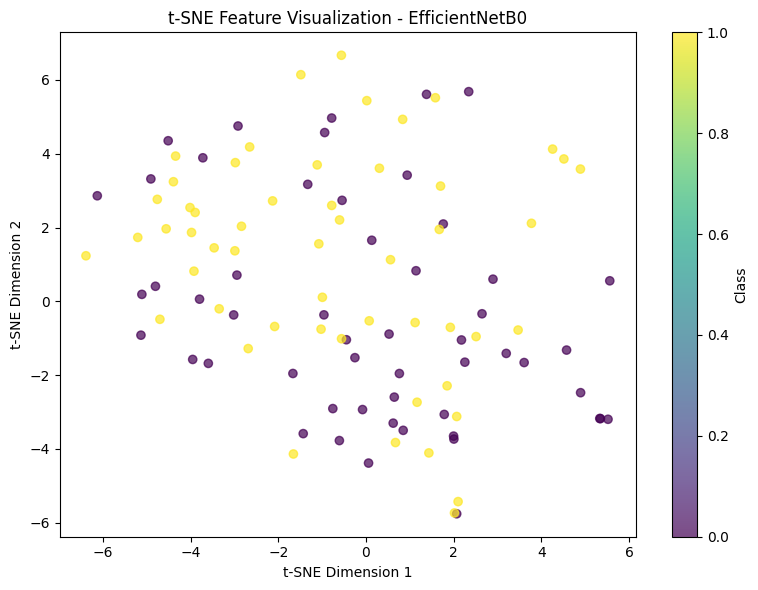


Feature Extraction Complete


In [12]:
# =============================
# 12. Feature Extraction and t-SNE Analysis
# =============================

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def extract_features(model, model_name, max_batches=10):

    test_gen.reset()
    features = []
    labels = []

    batches = min(max_batches, int(np.ceil(test_gen.samples / BATCH_SIZE)))

    dummy_input = np.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    _ = model(dummy_input, training=False)

    if model_name == "Simple CNN":

        feature_layer = model.get_layer("last_conv")

        feature_model = tf.keras.Model(
            inputs=model.inputs,
            outputs=feature_layer.output
        )

        layer_name = "last_conv"

        for _ in range(batches):

            x_batch, y_batch = next(test_gen)

            batch_features = feature_model.predict(x_batch, verbose=0)
            batch_features = batch_features.reshape(batch_features.shape[0], -1)

            features.append(batch_features)
            labels.append(np.argmax(y_batch, axis=1))

    else:

        base_model = None

        for layer in model.layers:
            if isinstance(layer, tf.keras.Model):
                base_model = layer
                break

        if base_model is None:
            raise ValueError(f"Could not locate base model for {model_name}")

        layer_name = base_model.name

        for _ in range(batches):

            x_batch, y_batch = next(test_gen)

            batch_features = base_model.predict(x_batch, verbose=0)
            batch_features = batch_features.reshape(batch_features.shape[0], -1)

            features.append(batch_features)
            labels.append(np.argmax(y_batch, axis=1))

    features = np.vstack(features)
    labels = np.concatenate(labels)

    return features, labels, layer_name


feature_results = {}

for model_name, model in trained_models.items():

    print("\n" + "=" * 80)
    print(f"Extracting Features: {model_name}")
    print("=" * 80)

    features, labels, layer_name = extract_features(model, model_name)

    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    features = np.clip(features, -10, 10)

    sparsity = float(np.mean(features == 0) * 100)
    mean_activation = float(np.mean(features))
    std_activation = float(np.std(features))

    feature_results[model_name] = {
        "feature_layer": layer_name,
        "feature_shape": list(features.shape),
        "feature_sparsity_percent": sparsity,
        "mean_activation": mean_activation,
        "std_activation": std_activation
    }

    print(f"Layer: {layer_name}")
    print(f"Shape: {features.shape}")
    print(f"Sparsity: {sparsity:.2f}%")
    print(f"Mean Activation: {mean_activation:.4f}")
    print(f"Std Activation: {std_activation:.4f}")

    n_samples = min(500, features.shape[0])

    safe_features = features[:n_samples]
    safe_features = StandardScaler().fit_transform(safe_features)
    safe_features = np.nan_to_num(safe_features, nan=0.0, posinf=0.0, neginf=0.0)
    safe_features = np.clip(safe_features, -10, 10)

    # Avoid PCA instability by using first 50 scaled feature columns
    safe_features = safe_features[:, :min(50, safe_features.shape[1])]

    perplexity_value = min(30, max(5, n_samples // 3))

    try:

        tsne = TSNE(
            n_components=2,
            random_state=SEED,
            perplexity=perplexity_value,
            init="random",
            learning_rate="auto"
        )

        tsne_features = tsne.fit_transform(safe_features)

        plt.figure(figsize=(8, 6))

        plt.scatter(
            tsne_features[:, 0],
            tsne_features[:, 1],
            c=labels[:n_samples],
            alpha=0.7
        )

        plt.title(f"t-SNE Feature Visualization - {model_name}")
        plt.xlabel("t-SNE Dimension 1")
        plt.ylabel("t-SNE Dimension 2")
        plt.colorbar(label="Class")
        plt.tight_layout()

        plt.savefig(
            VISUALS_DIR / f"tsne_{model_name.lower().replace(' ', '_')}.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    except Exception as e:
        print(f"t-SNE skipped for {model_name}: {e}")

print("\nFeature Extraction Complete")

In [13]:
for model_name in all_results.keys():
    if model_name in feature_results:
        all_results[model_name]["feature_analysis"] = {
            "feature_sparsity_percent": feature_results[model_name]["feature_sparsity_percent"],
            "activation_mean": feature_results[model_name]["mean_activation"],
            "activation_std": feature_results[model_name]["std_activation"],
            "feature_shape": feature_results[model_name]["feature_shape"],
            "feature_layer": feature_results[model_name]["feature_layer"]
        }

print("Feature analysis merged into all_results.")

Feature analysis merged into all_results.


In [14]:
# =============================
# 11. Export Results JSON and CSV
# =============================
comparison_rows = []
for model_name, r in all_results.items():
    comparison_rows.append({
        'model': model_name,
        'test_accuracy': r['test_accuracy'],
        'weighted_f1_score': r['weighted_f1_score'],
        'best_val_accuracy': r['best_val_accuracy'],
        'training_time_seconds': r['training_time_seconds'],
        'inference_time_seconds': r['inference_time_seconds'],
        'inference_time_per_image_ms': r['inference_time_per_image_ms'],
        'total_parameters': r['total_parameters'],
        'trainable_parameters': r['trainable_parameters'],
        'non_trainable_parameters': r['non_trainable_parameters'],
        'epochs_trained': r['epochs_trained'],
        'feature_sparsity_percent': r['feature_analysis']['feature_sparsity_percent'],
        'activation_mean': r['feature_analysis']['activation_mean'],
        'activation_std': r['feature_analysis']['activation_std'],
        'feature_shape': str(r['feature_analysis']['feature_shape'])
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(by='test_accuracy', ascending=False)
display(comparison_df)

json_path = RESULTS_DIR / 'cnn_lab_results.json'
csv_path = RESULTS_DIR / 'cnn_lab_comparison.csv'
with open(json_path, 'w') as f:
    json.dump({
        'created_at': datetime.now().isoformat(),
        'config': {'IMG_SIZE': IMG_SIZE, 'BATCH_SIZE': BATCH_SIZE, 'EPOCHS': EPOCHS, 'SEED': SEED},
        'results': all_results,
        'histories': histories
    }, f, indent=2)
comparison_df.to_csv(csv_path, index=False)
print('Saved:', json_path)
print('Saved:', csv_path)

,model,test_accuracy,weighted_f1_score,best_val_accuracy,training_time_seconds,inference_time_seconds,inference_time_per_image_ms,total_parameters,trainable_parameters,non_trainable_parameters,epochs_trained,feature_sparsity_percent,activation_mean,activation_std,feature_shape
1,VGG16,0.839623,0.838920,0.823529,288.649844,6.620742,62.459829,14780610,65922,14714688,8,74.326935,0.161775,0.562619,"[106, 25088]"
0,Simple CNN,0.698113,0.698006,0.722689,107.245079,0.510670,4.817639,11169218,11169218,0,20,93.701875,0.000936,0.005479,"[106, 346112]"
2,ResNet50,0.528302,0.525600,0.647059,102.779495,3.681279,34.729047,23850242,262530,23587712,9,94.559058,0.108672,0.740108,"[106, 100352]"
3,EfficientNetB0,0.500000,0.333333,0.504202,34.291445,3.055152,28.822186,4213797,164226,4049571,6,0.000000,-0.104293,0.461153,"[106, 62720]"


Saved: /Users/dare/img_align_celeba/cnn_capstone_outputs/results/cnn_lab_results.json
Saved: /Users/dare/img_align_celeba/cnn_capstone_outputs/results/cnn_lab_comparison.csv


## Analysis Report: Required Project Execution Questions

### 1. Environment and Setup
Training all four models simultaneously would require substantial GPU memory because each model stores parameters, activations, gradients, optimizer states, and batch tensors. A practical estimate is 12–24 GB or more if all four models are resident in memory at once, especially with ResNet50 and EfficientNetB0. A safer approach is to train models sequentially and clear unused models from memory when needed. If out-of-memory errors occur, reduce `BATCH_SIZE` from 32 to 16 or 8, reduce `IMG_SIZE`, train one model at a time, or restart the kernel between large transfer-learning runs.

### 2. Data Loading and Preprocessing
A validation split separates part of the training data for unbiased model tuning during training. It allows the model to train on one subset while monitoring generalization on another subset. If the same generator or same images were used for both training and validation, validation accuracy would be inflated because the model would be evaluated on images it already saw. This weakens evidence of generalization.

### 3. Model Architecture Implementation
Transfer-learning base layers are frozen initially because they already contain useful ImageNet feature extractors such as edge, texture, shape, and object-part detectors. Freezing reduces trainable parameters, lowers training time, reduces GPU memory demand, and limits overfitting on smaller datasets. Training all layers from scratch would require more data, more compute, and more epochs.

### 4. Training Process Management
`EarlyStopping` monitors validation accuracy and stops training after validation performance fails to improve for the defined patience window. `ReduceLROnPlateau` lowers the learning rate after validation loss plateaus. Together, they reduce wasted computation, improve convergence stability, and help prevent overfitting by stopping or slowing training when additional epochs are no longer improving validation performance.

### 5. Memory Management and Efficiency
The Simple CNN generally has a smaller architecture but can still create many parameters after flattening high-dimensional convolutional outputs. ResNet50 has a deeper feature extractor with many convolutional blocks and residual connections, so it stores more intermediate activations during training. Memory usage is driven mainly by activations, batch size, image size, gradients, and optimizer states. ResNet50 usually trains slower and requires more memory, although freezing the base model substantially reduces backpropagation cost.

### 6. Feature Extraction Implementation
The last convolutional layer is selected because it contains high-level spatial representations before the classifier compresses information into final class probabilities. For the Simple CNN, `last_conv` captures the deepest learned convolutional features. For VGG16, ResNet50, and EfficientNetB0, the base model output is appropriate because it represents the final high-level feature map learned from ImageNet before the custom classification head.

### 7. Batch Processing and Prediction
`test_gen.reset()` is called before prediction to ensure the generator starts at the first test batch. Without resetting, predictions could begin from the generator’s current internal pointer, producing missing, duplicated, or misaligned predictions. This is especially important when evaluating multiple models sequentially with the same generator.

### 8. Data Augmentation Impact
Rotation, shifting, zooming, and flipping increase training diversity by showing the model realistic image variations. This usually improves generalization but increases training time because augmented images are generated on the fly. Augmentation may slow early convergence because the model sees a harder and more variable training distribution, but it often reduces overfitting and improves validation/test performance.

### 9. Model Compilation and Optimization
Adam is appropriate because it adapts learning rates per parameter and generally converges efficiently across CNN architectures. Categorical crossentropy is appropriate because labels are one-hot encoded into two output classes using softmax. Binary crossentropy with a single sigmoid output would also be valid for binary classification. Alternative optimizers such as SGD with momentum may be useful when seeking stronger generalization or when fine-tuning with a carefully scheduled learning rate.

### 10. Reproducibility and Random Seeds
Randomness appears in train/validation/test splitting, initial weights in custom layers, batch ordering, data augmentation transforms, dropout masks, and some GPU operations. Setting NumPy, Python, and TensorFlow seeds improves reproducibility by making experiments more comparable across runs. Full determinism may still vary by hardware and backend implementation.

## Parameter Modification Questions

### 1. Batch Size Modification
Batch size 16 typically uses less memory and may generalize well because updates are noisier, but training can take longer. Batch size 64 uses more memory, may train faster per epoch on strong GPUs, but can converge to less general solutions on some datasets. Batch size 32 is a balanced default. The optimal batch size should be selected based on available GPU memory, training stability, and validation accuracy.

### 2. Learning Rate Adjustment
A learning rate of 0.0001 usually trains more slowly but more stably. A learning rate of 0.001 is a strong default for Adam and often converges efficiently. A learning rate of 0.01 may be too high and can cause unstable training, oscillating validation curves, or failure to converge. The best learning rate is the one with smooth loss reduction and the highest validation accuracy without instability.

### 3. Dropout Rate Experimentation
Dropout 0.3 applies lighter regularization and may improve performance when the model is underfitting. Dropout 0.5 is a balanced default. Dropout 0.8 is aggressive and can cause underfitting by removing too much information from the classifier head. The best dropout rate is the one that minimizes the gap between training and validation accuracy while preserving strong test accuracy.

### 4. Image Size Impact
Reducing image size to 128 lowers memory usage and speeds up training but can remove visual detail. Increasing image size to 384 increases memory usage and training time but may improve recognition if fine details matter. Transfer-learning models are commonly configured around 224×224 ImageNet preprocessing, so 224 is a practical and reliable default.

### 5. Architecture Depth Modification
Adding a Conv2D(256) block increases representational capacity and may improve feature extraction, but it also increases computation, memory usage, and overfitting risk. If the deeper model improves t-SNE class separation and test accuracy without a large train-validation gap, the added depth is beneficial. If not, the original architecture is preferable because it is simpler and faster.

## Bonus Challenge Guidance

**Fine-tuning:** Unfreezing the last 2–3 layers of the best transfer-learning model with a low learning rate such as 1e-5 may improve domain adaptation. It can also overfit if the dataset is small.

**Cross-validation:** K-fold cross-validation for the Simple CNN gives a more reliable estimate of accuracy variance across splits but increases compute time substantially.

**Ensemble Methods:** Averaging predictions from the top two models may improve robustness if the models make different errors. It may not be worth the extra inference cost for production.

**Model Compression:** Quantization and pruning can reduce model size and improve deployment efficiency, especially for mobile or edge inference.

**Real-time Inference:** EfficientNetB0 or the Simple CNN is usually better suited for mobile deployment because of lower inference cost compared with VGG16 or ResNet50, assuming accuracy remains acceptable.

In [16]:
# =============================
# 12. Optional Experiments Templates
# Run only if required by instructor or if time allows.
# =============================
RUN_OPTIONAL_EXPERIMENTS = False

if RUN_OPTIONAL_EXPERIMENTS:
    # Batch-size, learning-rate, dropout, image-size, architecture-depth experiments can be added here.
    # Keeping this disabled prevents long runtime during the main capstone execution.
    pass